In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
file_path = '/content/drive/MyDrive/csv/yahoo_stock.csv'
df = pd.read_csv(file_path)
df.head()

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107


In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)


data = df['Close']
print(data.head())

Date
2015-11-23    2086.590088
2015-11-24    2089.139893
2015-11-25    2088.870117
2015-11-26    2088.870117
2015-11-27    2090.110107
Name: Close, dtype: float64


In [9]:
# Check for missing values
print(df.isnull().sum())

# Basic info about the dataset
print(df.info())

# Summary statistics to spot outliers
print(df.describe())

High         0
Low          0
Open         0
Close        0
Volume       0
Adj Close    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1825 entries, 2015-11-23 to 2020-11-20
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   High       1825 non-null   float64
 1   Low        1825 non-null   float64
 2   Open       1825 non-null   float64
 3   Close      1825 non-null   float64
 4   Volume     1825 non-null   float64
 5   Adj Close  1825 non-null   float64
dtypes: float64(6)
memory usage: 99.8 KB
None
              High          Low         Open        Close        Volume  \
count  1825.000000  1825.000000  1825.000000  1825.000000  1.825000e+03   
mean   2660.718673  2632.817580  2647.704751  2647.856284  3.869627e+09   
std     409.680853   404.310068   407.169994   407.301177  1.087593e+09   
min    1847.000000  1810.099976  1833.400024  1829.079956  1.296540e+09   
25%    2348.350098  2322.250000 

In [10]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("Result: Data is Stationary")
    else:
        print("Result: Data is Non-Stationary")

check_stationarity(df['Close'])

ADF Statistic: -0.8703973870161453
p-value: 0.7975646340657463
Result: Data is Non-Stationary


Null values:
 High         0
Low          0
Open         0
Close        0
Volume       0
Adj Close    0
dtype: int64


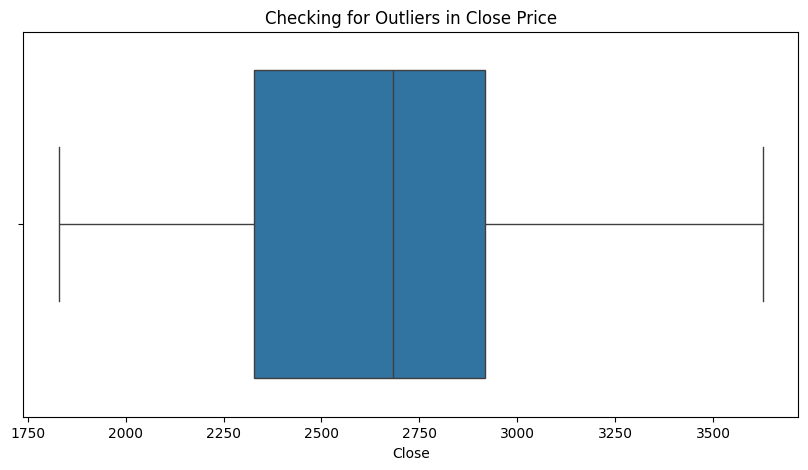

In [11]:
# Check for null values
print("Null values:\n", df.isnull().sum())

# Visualization to spot outliers
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Close'])
plt.title('Checking for Outliers in Close Price')
plt.show()

In [12]:
# Reset the index to get 'Date' as a column
df_final = df.reset_index()[['Date', 'Close']]

# Rename columns
df_final.columns = ['ds', 'y']

# Display the prepared dataframe
df_final.head()

,ds,y
0,2015-11-23,2086.590088
1,2015-11-24,2089.139893
2,2015-11-25,2088.870117
3,2015-11-26,2088.870117
4,2015-11-27,2090.110107


In [13]:
from prophet import Prophet

# Initialize the model with holiday effects
model = Prophet(daily_seasonality=True)
model.add_country_holidays(country_name='US')

# Fit the model
model.fit(df_final)

In [14]:
# Create a dataframe for the next 365 days
future = model.make_future_dataframe(periods=365)

# Predict the future values
forecast = model.predict(future)

# Show the last few rows of forecast
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
2185,2021-11-16,3847.181314,2809.155341,4917.110705
2186,2021-11-17,3851.675925,2809.947985,4946.558893
2187,2021-11-18,3852.988728,2808.395016,4964.763316
2188,2021-11-19,3855.898537,2763.046530,4939.213500
2189,2021-11-20,3857.047056,2791.942373,4943.700443


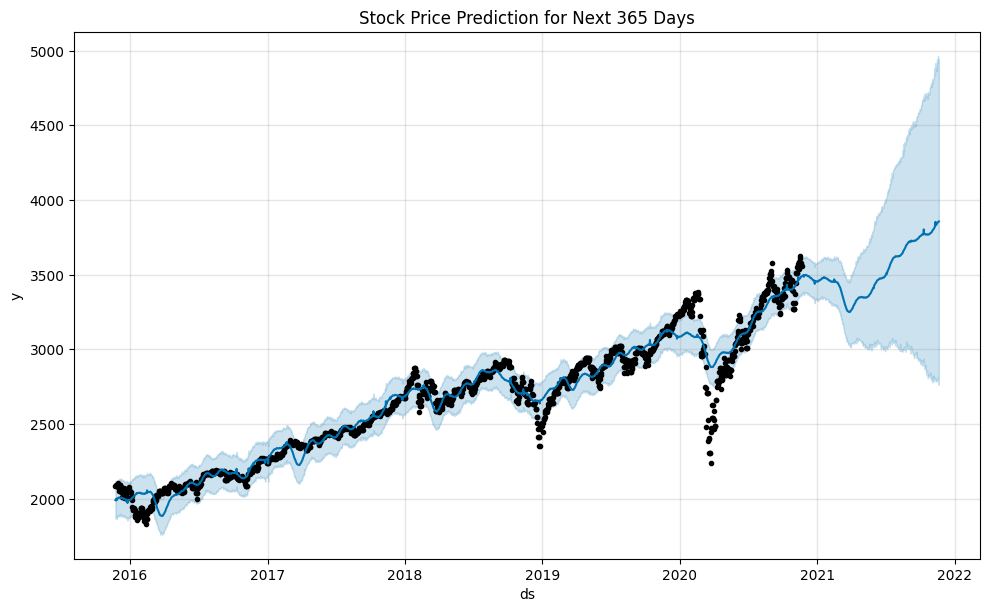

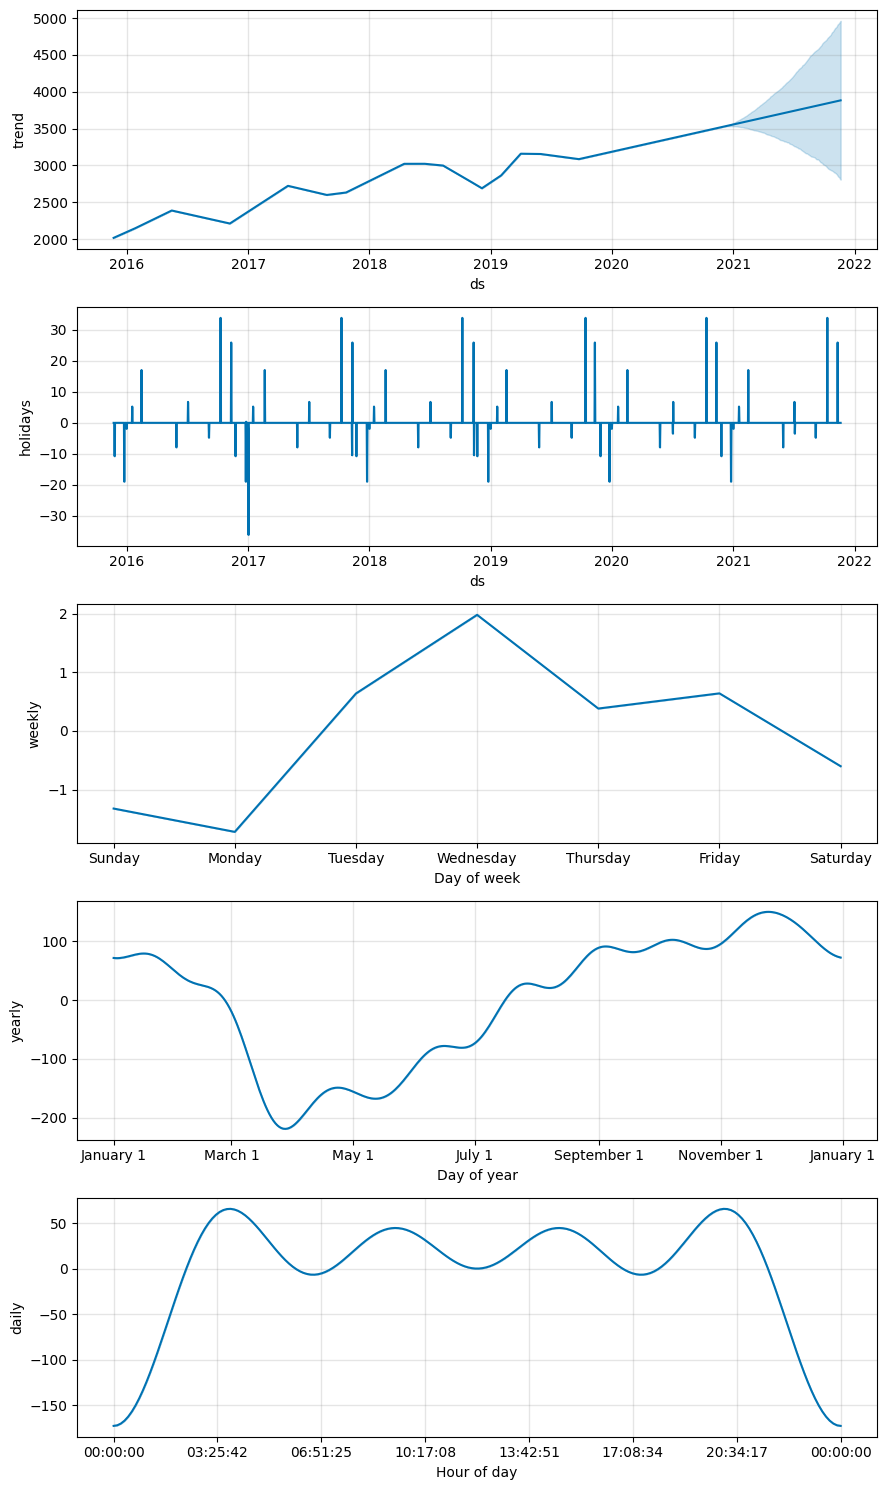

In [15]:
# Plot the forecast
fig1 = model.plot(forecast)
plt.title('Stock Price Prediction for Next 365 Days')
plt.show()

# Plot components (Trend, Weekly, Yearly seasonality)
fig2 = model.plot_components(forecast)
plt.show()

INFO:prophet:Making 5 forecasts with cutoffs between 2017-12-01 00:00:00 and 2019-11-21 00:00:00


  0%|          | 0/5 [00:00<?, ?it/s]

  horizon        mae        rmse      mape
0 37 days  69.536351   97.044404  0.025245
1 38 days  73.356914  101.624932  0.026619
2 39 days  76.726161  105.426420  0.027798
3 40 days  80.244224  109.382885  0.029022
4 41 days  83.907273  113.558507  0.030295


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


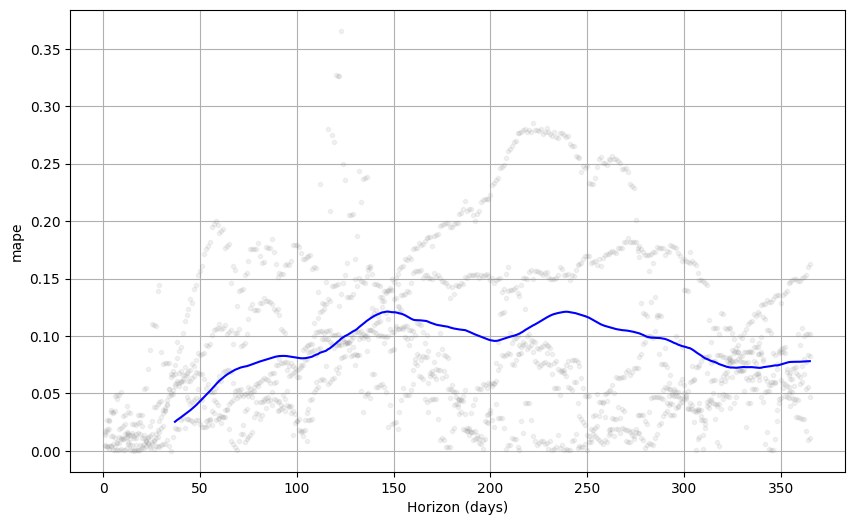

In [16]:
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import numpy as np

# 1. Prepare the model with potential multiplicative seasonality
model = Prophet(seasonality_mode='multiplicative', daily_seasonality=True)
model.add_country_holidays(country_name='US')
model.fit(df_final)

# 2. Cross-validation (730 days training, 365 days forecast)
df_cv = cross_validation(model, initial='730 days', period='180 days', horizon='365 days')

# 3. Calculate metrics
df_p = performance_metrics(df_cv)

# 4. Show accuracy metrics (MAE, RMSE, MAPE)
print(df_p[['horizon', 'mae', 'rmse', 'mape']].head())

# 5. Plotting MAPE for accuracy visualization
fig = plot_cross_validation_metric(df_cv, metric='mape')

In [17]:
import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import itertools

# Define the parameter grid
param_grid = {
    'changepoint_prior_scale': [0.001, 0.05, 0.5],
    'seasonality_prior_scale': [0.01, 1.0, 10.0],
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
mapes = [] # Store the MAPE for each combination

# Use cross validation to evaluate all parameters
for params in all_params:
    m = Prophet(**params).fit(df_final) # Fit model with given params
    df_cv = cross_validation(m, initial='730 days', period='180 days', horizon='365 days', parallel="processes")
    df_p = performance_metrics(df_cv, rolling_window=1)
    mapes.append(df_p['mape'].values[0])

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['mape'] = mapes
best_params = all_params[np.argmin(mapes)]

print(f"Best Parameters: {best_params}")

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 5 forecasts with cutoffs between 2017-12-01 00:00:00 and 2019-11-21 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x79572e75be00>
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 5 forecasts with cutoffs between 2017-12-01 00:00:00 and 2019-11-21 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7957272b74d0>
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 5 forecasts with cutoffs between 2017-12-01 00:00:00 and 2019-11-21 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x795727271490>
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seaso

Best Parameters: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 0.01}


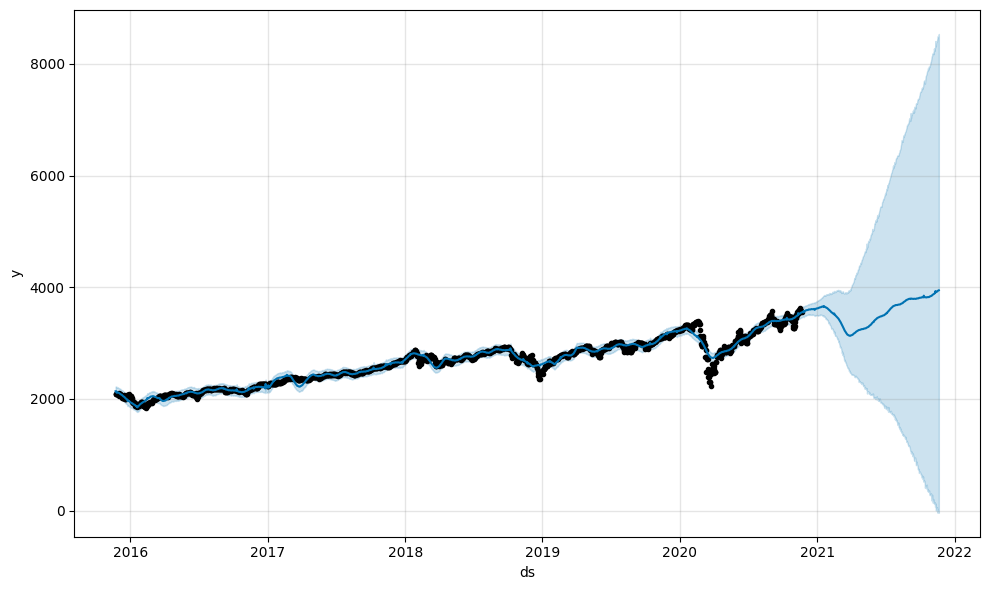

In [18]:
# Final model with best parameters
final_model = Prophet(
    changepoint_prior_scale=0.5,
    seasonality_prior_scale=0.01,
    daily_seasonality=True
)

# Adding US holidays for better accuracy
final_model.add_country_holidays(country_name='US')

# Fitting the model to the data
final_model.fit(df_final)

# Create future dataframe for 365 days
future_final = final_model.make_future_dataframe(periods=365)

# Forecast
forecast_final = final_model.predict(future_final)

# Plotting the final result
fig_final = final_model.plot(forecast_final)
